<a href="https://colab.research.google.com/github/rrivasr12/Aprendizaje_de_Maquina/blob/master/analisis_s3f3_fase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import pandas as pd

In [2]:
df = pd.read_csv(Path("Clean_Dataset.csv"), sep=",", decimal=".")

In [6]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [11]:
# Completitud y consistencia
print(df.isnull().sum())
print('Duplicados:', df.duplicated().sum())
# Detección de outliers (IQR) en variables numéricas
for col in ['price', 'duration', 'days_left']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: q1={q1} q3={q3} lower={lower:.2f} upper={upper:.2f} outliers={n_out} ({100*n_out/len(df):.2f}%)')

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
Duplicados: 0
price: q1=4783.0 q3=42521.0 lower=-51824.00 upper=99128.00 outliers=123 (0.04%)
duration: q1=6.83 q3=16.17 lower=-7.18 upper=30.18 outliers=2110 (0.70%)
days_left: q1=15.0 q3=38.0 lower=-19.50 upper=72.50 outliers=0 (0.00%)


In [26]:
df[["duration", "days_left", "price"]].describe().round(2)

,duration,days_left,price
count,300153.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00


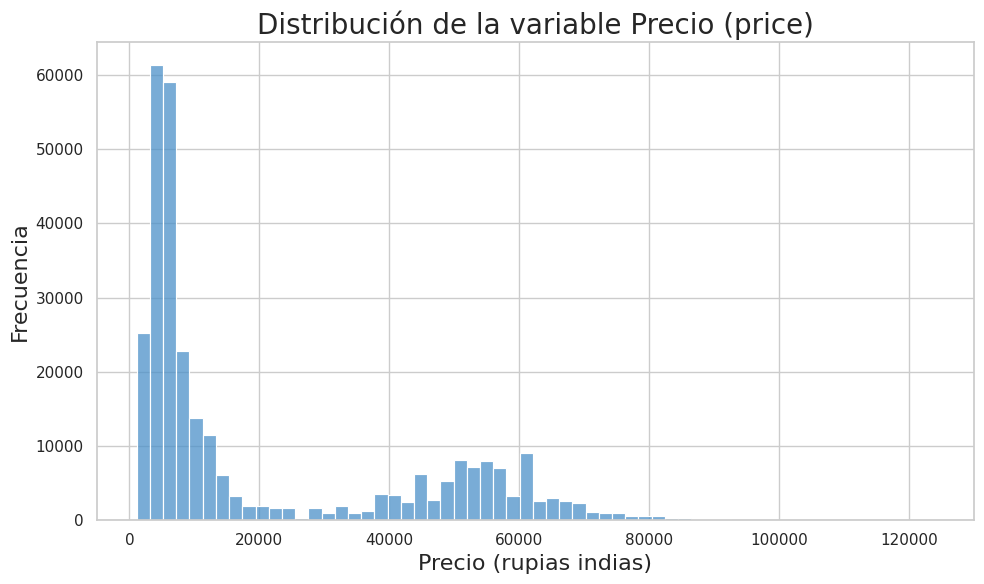

In [18]:
import seaborn as sns, matplotlib.pyplot as plt
# Histograma del precio
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df["price"],bins=60,color="#4C91C9",edgecolor="white")

plt.title("Distribución de la variable Precio (price)", fontsize=20)
plt.xlabel("Precio (rupias indias)", fontsize=16)
plt.ylabel("Frecuencia", fontsize=16)

plt.xlim(-5000, 130000)
plt.tight_layout()
plt.show()

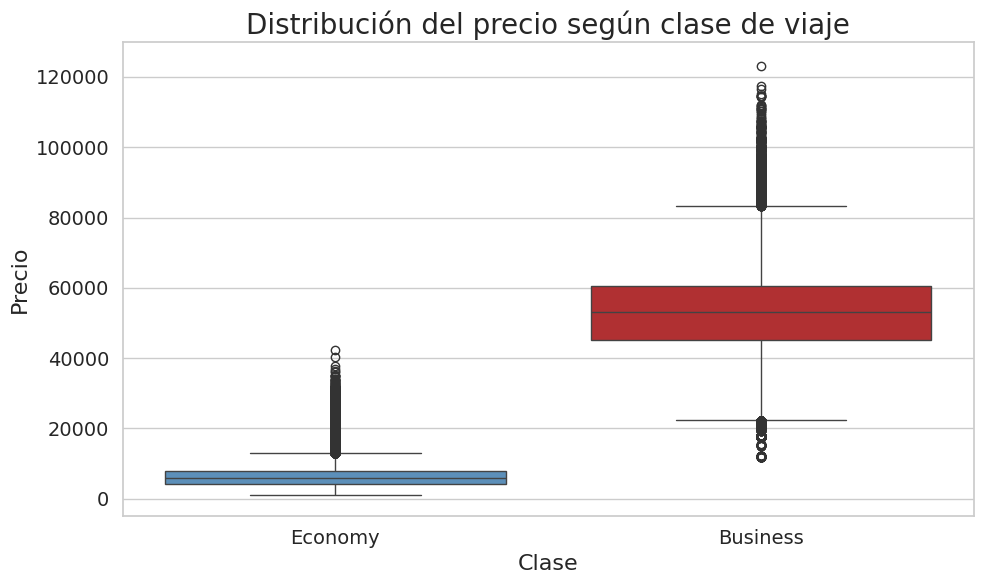

In [21]:
# Boxplot de precio por clase
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(data=df,x="class",y="price",order=["Economy", "Business"],hue="class",palette={"Economy": "#4C91C9","Business": "#C51B1D"},
    legend=False,
    flierprops={"marker": "o","markerfacecolor": "none","markeredgecolor": "#333333","markersize": 6,"linestyle": "none"})

plt.title("Distribución del precio según clase de viaje",fontsize=20)
plt.xlabel("Clase", fontsize=16)
plt.ylabel("Precio", fontsize=16)
plt.tick_params(axis="both", labelsize=14)
plt.ylim(-5000, 130000)
plt.tight_layout()
plt.show()

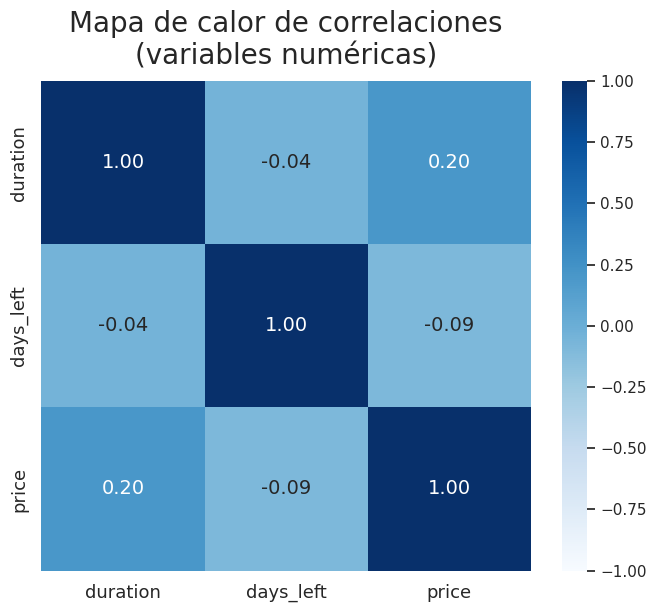

In [22]:
# Mapa de calor de correlaciones
variables = ["duration", "days_left", "price"]
matriz_correlacion = df[variables].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(matriz_correlacion,annot=True,fmt=".2f",cmap="Blues",vmin=-1,vmax=1,square=True,annot_kws={"fontsize": 14},
    cbar_kws={"ticks":[-1, -0.75, -0.50, -0.25, 0, 0.25, 0.50, 0.75, 1]})

plt.title("Mapa de calor de correlaciones\n(variables numéricas)",fontsize=20,pad=12)
plt.xticks(rotation=0, fontsize=13)
plt.yticks(rotation=90, fontsize=13)
plt.tight_layout()
plt.show()

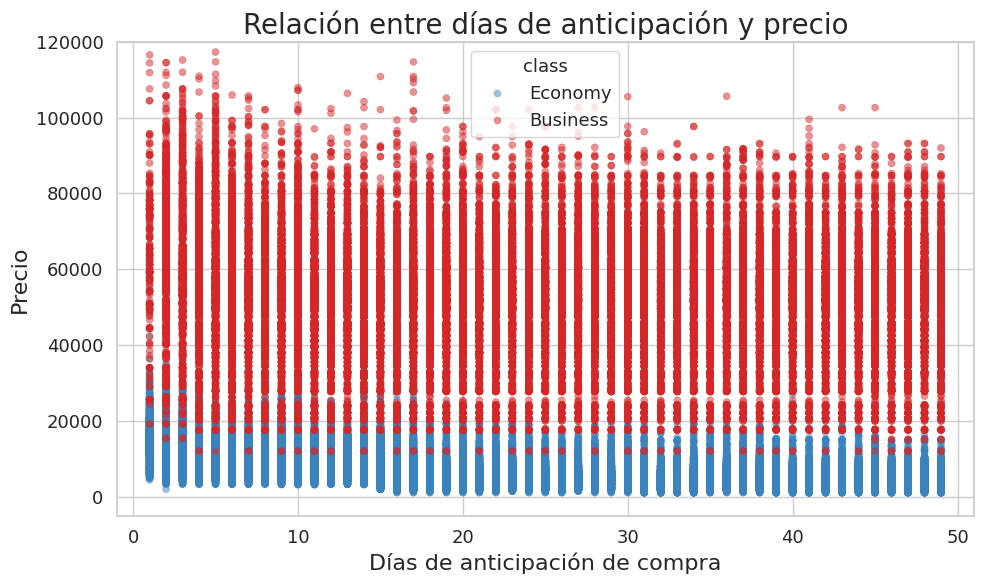

In [23]:
# Dispersión días de anticipación vs precio
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df,x="days_left",y="price",hue="class",hue_order=["Economy", "Business"],palette={"Economy": "#3B83BD","Business": "#D62728"},
    alpha=0.50,s=25,edgecolor=None)

plt.title("Relación entre días de anticipación y precio",fontsize=20)
plt.xlabel("Días de anticipación de compra", fontsize=16)
plt.ylabel("Precio", fontsize=16)
plt.xlim(-1, 51)
plt.ylim(-5000, 120000)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(title="class",loc="upper center",fontsize=13,title_fontsize=13)
plt.tight_layout()
plt.show()

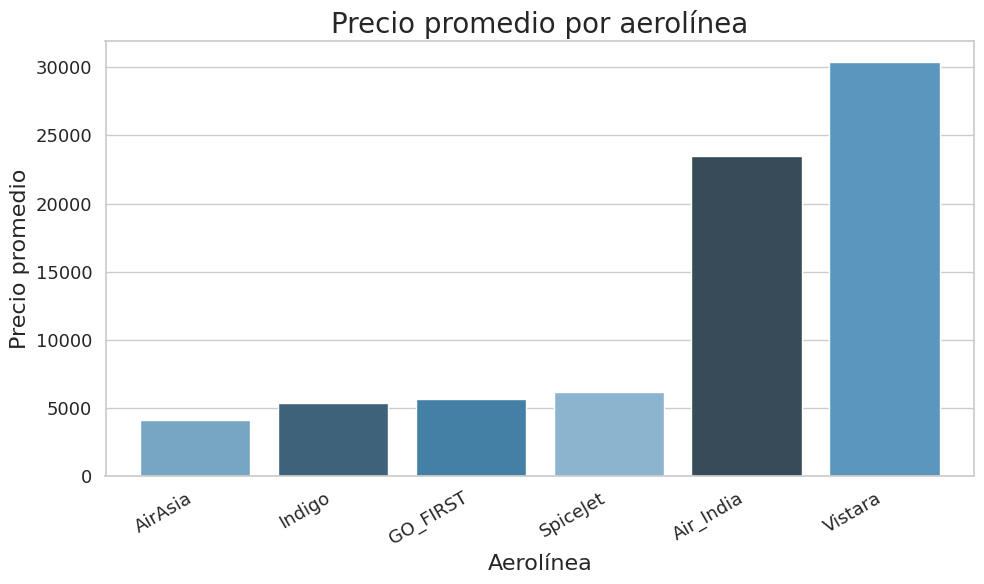

In [24]:
# Precio promedio por aerolínea
sns.set_theme(style="whitegrid")

precio_promedio = (df.groupby("airline")["price"].mean().sort_values())

colores = ["#77A6C5","#3E627A","#447FA6","#8DB4CF","#374B59","#5A96BE"]

ax = precio_promedio.plot(kind="bar",figsize=(10, 6),color=colores,edgecolor="white",width=0.8)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

plt.title("Precio promedio por aerolínea", fontsize=20)
plt.xlabel("Aerolínea", fontsize=16)
plt.ylabel("Precio promedio", fontsize=16)
plt.xticks(rotation=30, ha="right", fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
cat_cols = ['airline','source_city','departure_time','stops','arrival_time','destination_city','class']
num_cols = ['duration','days_left']
X = df[cat_cols + num_cols]; y = df['price']
# Partición 70% train / 15% validación / 15% prueba
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),('num', StandardScaler(), num_cols)])

In [37]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mlp = TransformedTargetRegressor(
    regressor=MLPRegressor(hidden_layer_sizes=(32, 16),max_iter=500,early_stopping=True,validation_fraction=0.15,n_iter_no_change=20,random_state=42),
    transformer=StandardScaler())

modelos = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=30, max_depth=12),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=40, max_depth=3),
    'MLP (proxy DL)': mlp
  }

resultados_largos = []
for nombre, modelo in modelos.items():
    pipe = Pipeline([("pre", pre),("model", modelo)])
    pipe.fit(X_train, y_train)

    for conjunto, X_eval, y_eval in [("Train", X_train, y_train),("Test", X_test, y_test)]:
        pred = pipe.predict(X_eval)
        resultados_largos.append({
            "Modelo": nombre,
            "Conjunto": conjunto,
            "RMSE": np.sqrt(mean_squared_error(y_eval, pred)),
            "MAE": mean_absolute_error(y_eval, pred),
            "R²": r2_score(y_eval, pred)
        })
metricas_df = pd.DataFrame(resultados_largos)
display(metricas_df.round(4))

,Modelo,Conjunto,RMSE,MAE,R²
0,Ridge,Train,6755.9401,4578.8101,0.9114
1,Ridge,Test,6666.6441,4528.6524,0.9129
2,Random Forest,Train,3795.5254,2060.1391,0.9720
3,Random Forest,Test,3945.5935,2135.8831,0.9695
4,Gradient Boosting,Train,5293.1693,3179.2711,0.9456
5,Gradient Boosting,Test,5253.3568,3158.7013,0.9459
6,MLP (proxy DL),Train,3864.8863,2296.7541,0.9710
7,MLP (proxy DL),Test,3912.8668,2322.6494,0.9700


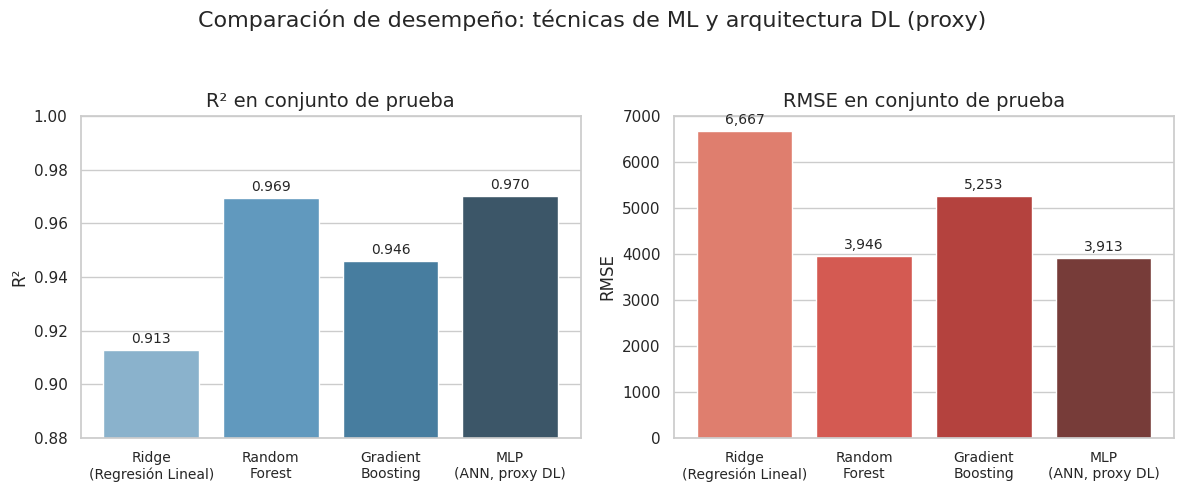

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Seleccionar solamente las métricas del conjunto de prueba
orden = [
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
    "MLP (proxy DL)"
]

test = (
    metricas_df[metricas_df["Conjunto"] == "Test"]
    .set_index("Modelo")
    .loc[orden]
    .reset_index()
)

etiquetas = [
    "Ridge\n(Regresión Lineal)",
    "Random\nForest",
    "Gradient\nBoosting",
    "MLP\n(ANN, proxy DL)"
]

colores_r2 = [
    "#8AB2CC",
    "#6199BE",
    "#477D9F",
    "#3C5668"
]

colores_rmse = [
    "#DF7E6E",
    "#D45A52",
    "#B4423E",
    "#773C39"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

fig.suptitle(
    "Comparación de desempeño: técnicas de ML y arquitectura DL (proxy)",
    fontsize=16
)

# --------------------------------
# Gráfico de R²
# --------------------------------
barras_r2 = axes[0].bar(
    etiquetas,
    test["R²"],
    color=colores_r2,
    edgecolor="white"
)

axes[0].set_title(
    "R² en conjunto de prueba",
    fontsize=14
)

axes[0].set_ylim(0.88, 1.00)
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", labelsize=10)
axes[0].grid(axis="x", visible=False)

axes[0].bar_label(
    barras_r2,
    labels=[f"{valor:.3f}" for valor in test["R²"]],
    padding=3,
    fontsize=10
)

# --------------------------------
# Gráfico de RMSE
# --------------------------------
barras_rmse = axes[1].bar(
    etiquetas,
    test["RMSE"],
    color=colores_rmse,
    edgecolor="white"
)

axes[1].set_title(
    "RMSE en conjunto de prueba",
    fontsize=14
)

axes[1].set_ylim(0, 7000)
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", labelsize=10)
axes[1].grid(axis="x", visible=False)

axes[1].bar_label(
    barras_rmse,
    labels=[f"{valor:,.0f}" for valor in test["RMSE"]],
    padding=3,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

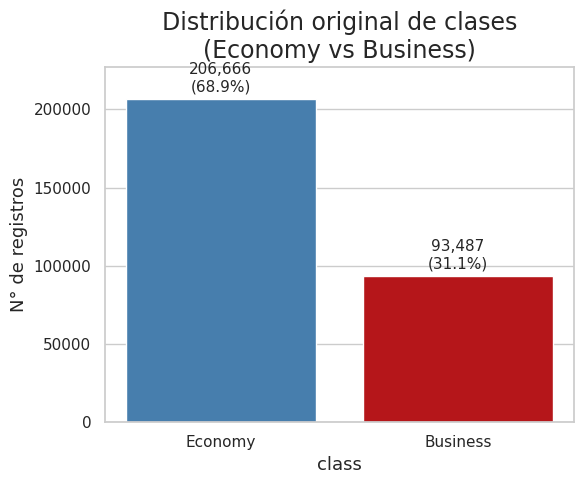

In [42]:
sns.set_theme(style="whitegrid")
orden = ["Economy", "Business"]
conteo = (df["class"].value_counts().reindex(orden))

porcentaje = conteo / conteo.sum() * 100
fig, ax = plt.subplots(figsize=(6, 5))
barras = ax.bar(conteo.index,conteo.values,color=["#477EAD", "#B5161A"],edgecolor="white",width=0.8)

ax.bar_label(barras,labels=[f"{cantidad:,.0f}\n({porc:.1f}%)" for cantidad, porc in zip(conteo, porcentaje)],padding=3,fontsize=11)

ax.set_title("Distribución original de clases\n(Economy vs Business)",fontsize=17)
ax.set_xlabel("class", fontsize=13)
ax.set_ylabel("N° de registros", fontsize=13)
ax.set_ylim(0, conteo.max() * 1.10)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Objetivo: 1 = Business; 0 = Economy
y_clf = (df["class"] == "Business").astype(int)

# Variables predictoras
X_clf = df.drop(columns=["class"])

# División estratificada
X_train_clf, X_test_clf, y_train_clf, y_test_clf = (train_test_split(X_clf,y_clf,test_size=0.20,random_state=42,stratify=y_clf))

# Identificación automática de columnas
columnas_numericas = X_clf.select_dtypes(include="number").columns.tolist()

columnas_categoricas = X_clf.select_dtypes(exclude="number").columns.tolist()

# Preprocesamiento numérico
pre_num = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

# Preprocesamiento categórico
pre_cat = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])

pre_clf = ColumnTransformer([("num", pre_num, columnas_numericas),("cat", pre_cat, columnas_categoricas)])

# Ajustar solamente con entrenamiento
X_train_enc = pre_clf.fit_transform(X_train_clf)

# Aplicar la misma transformación a prueba
X_test_enc = pre_clf.transform(X_test_clf)

print("X_train_enc:", X_train_enc.shape)
print("X_test_enc: ", X_test_enc.shape)
print("y_train_clf:", y_train_clf.shape)
print("y_test_clf: ", y_test_clf.shape)

X_train_enc: (240122, 1594)
X_test_enc:  (60031, 1594)
y_train_clf: (240122,)
y_test_clf:  (60031,)


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

X_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X_train_enc, y_train_clf)

X_over, y_over = RandomOverSampler(random_state=42).fit_resample(X_train_enc, y_train_clf)

X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train_enc, y_train_clf)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score,recall_score,f1_score)

escenarios = {
    "Original": (X_train_enc, y_train_clf),
    "Undersampling": (X_under, y_under),
    "Oversampling": (X_over, y_over),
    "SMOTE": (X_smote, y_smote)
}

resultados = []

for nombre, (Xb, yb) in escenarios.items():

    clf = LogisticRegression(max_iter=1000,random_state=42)

    clf.fit(Xb, yb)
    pred = clf.predict(X_test_enc)

    resultados.append({
        "Técnica": nombre,
        "Precisión": precision_score(y_test_clf, pred),
        "Recall": recall_score(y_test_clf, pred),
        "F1 Business": f1_score(y_test_clf, pred)
    })

resultados_balanceo = pd.DataFrame(resultados)
display(resultados_balanceo.round(4))